# MicroProyecto # 2 de Machine Learning No Supervisado — MAIA

**Nombre de los estudiantes:**  Jairo Alexander López Garcia -  Miguel Angel Rodriguez Marin

**Código:**  `202615506`  -  `202612426`

**Maestría:** Maestría en Inteligencia Artificial (MAIA)

**Fecha:**  06/15/2026


## 0. Importación de librerías requeridas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Carga del Dataset

In [ ]:
df = pd.read_excel('./data/Datos_textosODS.xlsx')
df.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


## 2. Preparacion de los Datos

### Verificacion de nulos y Duplicados

In [ ]:
print(df.isnull().sum())
print(df.duplicated(subset='textos').sum())

textos    0
ODS       0
dtype: int64
0


### Definicion de Tokenizador

In [ ]:
tokenizer = RegexpTokenizer(r'[a-zA-ZáéíóúñÁÉÍÓÚÑüÜ]+')
stopwords_es = stopwords.words('spanish')
stemmer = SnowballStemmer('spanish')

### Prueba de Tokenizador

In [ ]:
texto_ejemplo = df['textos'].iloc[0]
tokenizer.tokenize(texto_ejemplo.lower())

['aprendizaje',
 'y',
 'educación',
 'se',
 'consideran',
 'sinónimos',
 'de',
 'escolarización',
 'formal',
 'las',
 'organizaciones',
 'auxiliares',
 'como',
 'las',
 'editoriales',
 'de',
 'educación',
 'las',
 'juntas',
 'examinadoras',
 'y',
 'las',
 'organizaciones',
 'de',
 'formación',
 'de',
 'docentes',
 'se',
 'consideran',
 'extensiones',
 'de',
 'los',
 'acuerdos',
 'establecidos',
 'por',
 'los',
 'gobiernos',
 'este',
 'marco',
 'de',
 'comprensión',
 'se',
 'ha',
 'vuelto',
 'cada',
 'vez',
 'más',
 'inadecuado']

### Funcion de preprocesamiento

In [ ]:
def text_preprocess(text):
    tokenizer = RegexpTokenizer(r'[a-zA-ZáéíóúñÁÉÍÓÚÑüÜ]+')
    stemmer = SnowballStemmer('spanish')
    
    tokens = tokenizer.tokenize(text.lower())
    tokens = [token for token in tokens if token not in stopwords_es]
    tokens = [stemmer.stem(token) for token in tokens]
    
    return ' '.join(tokens)

### Prueba de la Funcion

In [ ]:
text_preprocess(df['textos'].iloc[0])

'aprendizaj educ consider sinon escolariz formal organiz auxiliar editorial educ junt examin organiz formacion docent consider extension acuerd establec gobi marc comprension vuelt cad vez inadecu'

### Separacion de datos

In [ ]:
X = df['textos']
y = df['ODS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=32)

### Vectorizador TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(preprocessor=text_preprocess)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_train_tfidf.shape

(7724, 5995)

In [ ]:
componentes_a_probar = [10, 12, 15, 18, 20]
varianza_acumulada = []

for n in componentes_a_probar:
    tsvd_prueba = TruncatedSVD(n_components=n, random_state=32)
    tsvd_prueba.fit(X_train_tfidf)
    varianza_acumulada.append(tsvd_prueba.explained_variance_ratio_.sum())
    print(n, tsvd_prueba.explained_variance_ratio_.sum())

10 0.054647515445620146
12 0.06156289645174339
15 0.07083972821151023
18 0.07899670679986093
20 0.08416308079861955


In [ ]:
tsvd = TruncatedSVD(n_components=18, random_state=32)
X_train_lsa = tsvd.fit_transform(X_train_tfidf)
X_train_lsa.shape

(7724, 18)

In [ ]:
terminos = vectorizer.get_feature_names_out()

def mostrar_topico(componente_idx, n_palabras=10):
    pesos = tsvd.components_[componente_idx]
    indices_top = np.argsort(np.abs(pesos))[::-1][:n_palabras]
    
    print(f"--- Tópico {componente_idx} ---")
    for idx in indices_top:
        print(f"  {terminos[idx]}: {pesos[idx]:.4f}")
    print()

for i in range(5):
    mostrar_topico(i)

--- Tópico 0 ---
  pais: 0.1440
  pued: 0.1354
  polit: 0.1350
  desarroll: 0.1348
  mujer: 0.1340
  agu: 0.1164
  trabaj: 0.1157
  educ: 0.1093
  gener: 0.1056
  derech: 0.1028

--- Tópico 1 ---
  agu: 0.4554
  mujer: -0.3960
  energ: 0.2062
  trabaj: -0.2033
  derech: -0.2016
  hombr: -0.1659
  educ: -0.1440
  niñ: -0.1203
  cost: 0.1078
  laboral: -0.1056

--- Tópico 2 ---
  derech: 0.5624
  internacional: 0.2469
  human: 0.2307
  pobrez: -0.1569
  ingres: -0.1542
  articul: 0.1439
  trabaj: -0.1177
  polit: 0.1091
  educ: -0.1058
  tribunal: 0.1053

--- Tópico 3 ---
  mujer: 0.3589
  agu: 0.3253
  escuel: -0.2775
  educ: -0.2747
  estudi: -0.2064
  docent: -0.1670
  evalu: -0.1517
  hombr: 0.1475
  gener: 0.1471
  aprendizaj: -0.1285

--- Tópico 4 ---
  agu: 0.6470
  energ: -0.3493
  energet: -0.1597
  educ: 0.1491
  electr: -0.1432
  renov: -0.1394
  escuel: 0.1229
  tecnolog: -0.1039
  desarroll: -0.0996
  climat: -0.0994



### Contruccion del Modelo

In [ ]:
steps = [
    ("vectorizer", TfidfVectorizer(preprocessor=text_preprocess)),
    ("dimred", TruncatedSVD(n_components=18, random_state=32)),
    ("model", LogisticRegression(max_iter=500, random_state=32)),
]

pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('dimred', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](16,)","[ 1, 2, 3,...,14,15,16]"
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function tex...x7f1de7e0bf60>
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",3
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [ ]:
y_pred_base = pipeline.predict(X_test)
print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           1       0.84      0.78      0.81       101
           2       0.62      0.58      0.60        74
           3       0.79      0.89      0.84       179
           4       0.83      0.93      0.88       205
           5       0.91      0.87      0.89       214
           6       0.86      0.94      0.90       139
           7       0.80      0.91      0.85       158
           8       0.62      0.47      0.54        89
           9       0.56      0.51      0.53        69
          10       0.77      0.63      0.69        70
          11       0.63      0.79      0.70       122
          12       0.86      0.29      0.43        62
          13       0.77      0.73      0.75        93
          14       0.56      0.59      0.57        75
          15       0.53      0.14      0.22        66
          16       0.78      0.92      0.85       216

    accuracy                           0.77      1932
   macro avg       0.73   

### Busqueda de Hiperparametros

In [ ]:
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=32),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
{'model__C': 10, 'model__class_weight': None}
0.7266060379412692


### Evaluacion del Modelo

In [ ]:
mejor_pipeline = grid.best_estimator_
y_pred_final = mejor_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           1       0.86      0.77      0.81       101
           2       0.64      0.64      0.64        74
           3       0.85      0.89      0.87       179
           4       0.88      0.92      0.90       205
           5       0.91      0.91      0.91       214
           6       0.87      0.94      0.91       139
           7       0.84      0.87      0.85       158
           8       0.63      0.51      0.56        89
           9       0.54      0.57      0.55        69
          10       0.76      0.69      0.72        70
          11       0.74      0.78      0.76       122
          12       0.79      0.48      0.60        62
          13       0.77      0.75      0.76        93
          14       0.65      0.59      0.62        75
          15       0.60      0.61      0.60        66
          16       0.83      0.91      0.87       216

    accuracy                           0.80      1932
   macro avg       0.76   

### Matriz de Confusion

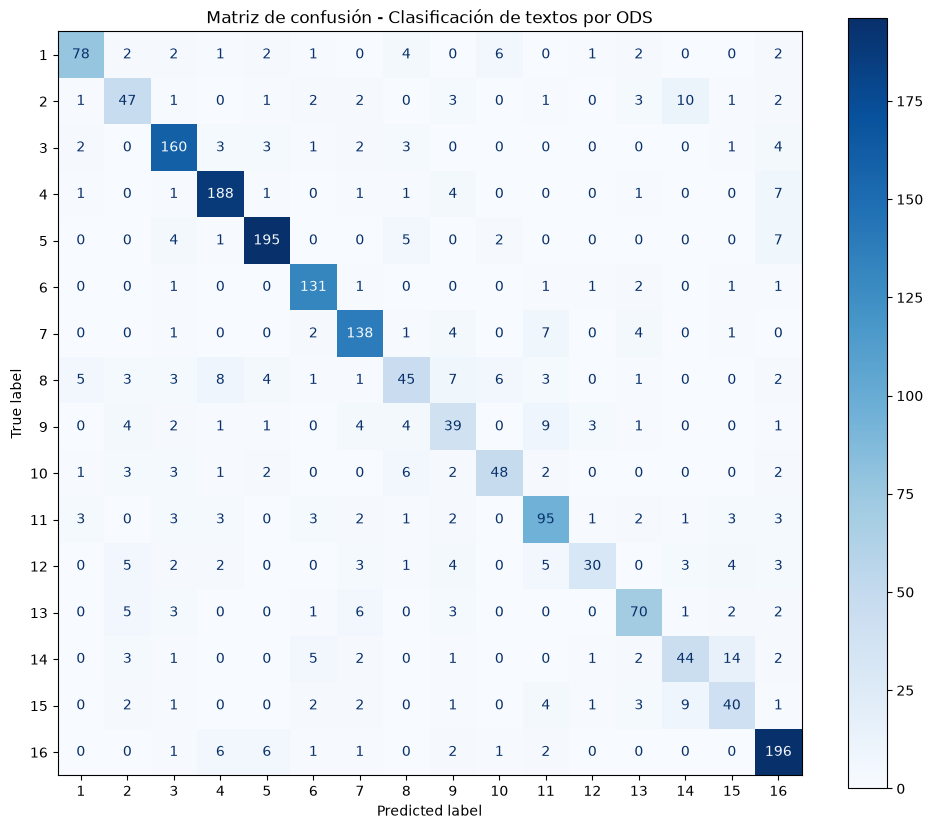

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=ax, cmap='Blues')
plt.title("Matriz de confusión - Clasificación de textos por ODS")
plt.show()

### Calsifiacion de prueba

In [ ]:
idx_ods4_test = X_test[y_test == 4].index
idx_ods12_test = X_test[y_test == 12].index
idx_ods15_test = X_test[y_test == 15].index
idx_ods16_test = X_test[y_test == 16].index

ejemplos_idx = [idx_ods4_test[0], idx_ods12_test[0], idx_ods15_test[2], idx_ods16_test[0]]

for idx in ejemplos_idx:
    texto = df.loc[idx, 'textos']
    ods_real = df.loc[idx, 'ODS']
    ods_predicho = mejor_pipeline.predict([texto])[0]
    
    print(f"Texto: {texto[:200]}...")
    print(f"ODS real: {ods_real} | ODS predicho: {ods_predicho}")
    print()

Texto: Dado el alcance del cambio en las prácticas docentes que requiere el nuevo currículo, Costa Rica podría encontrar valor en estándares que ofrezcan una guía más específica a los docentes en cuanto a lo...
ODS real: 4 | ODS predicho: 4

Texto: Es evidente que la escasez de recursos naturales presenta un problema global a largo plazo, motivo por el cual aquellas empresas que quieran anticiparse al futuro deberían explorar la posibilidad de i...
ODS real: 12 | ODS predicho: 12

Texto: El sector forestal contribuye a las actividades al aire libre construyendo y manteniendo caminos forestales y llevando a cabo medidas silvícolas para aumentar la accesibilidad de los bosques. El uso d...
ODS real: 15 | ODS predicho: 14

Texto: El 26 de junio de 2002 se adoptó en Alemania el código penal internacional tras el voto unánime del Bundestag (Deutscher Bundestag, 2002).1 Tras la ratificación del Tratado de Roma, la nueva norma ada...
ODS real: 16 | ODS predicho: 16

